In [1]:
from pathlib import Path
import json
import ast

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter

In [2]:
PROJECT_ROOT = Path.cwd()
RAW_DATA_DIR = PROJECT_ROOT / "data" / "raw"

json_file = RAW_DATA_DIR / "games.json"

with open(json_file, "r", encoding="utf-8") as f:
    games = json.load(f)

print(f"Loaded {len(games):,} games")

Loaded 135,140 games


In [3]:
records = []

for appid, game in games.items():
    row = game.copy()
    row["appid"] = int(appid)
    records.append(row)

df = pd.DataFrame(records)

print(f"Dataframe shape: {df.shape}")
df.head()

Dataframe shape: (135140, 43)


,name,release_date,required_age,price,dlc_count,detailed_description,about_the_game,short_description,reviews,header_image,...,negative,estimated_owners,average_playtime_forever,average_playtime_2weeks,median_playtime_forever,median_playtime_2weeks,discount,peak_ccu,tags,appid
0,Black Dragon Mage Playtest,"Aug 1, 2023",0,0.00,0,,,,,https://shared.akamai.steamstatic.com/store_it...,...,0,0 - 0,0,0,0,0,0,0,[],2539430
1,Supipara - Chapter 1 Spring Has Come!,"Jul 29, 2016",0,5.24,0,"Springtime, April: when the cherry trees come ...","Springtime, April: when the cherry trees come ...","Spring has come, and our protagonist, Yukinari...",,https://shared.akamai.steamstatic.com/store_it...,...,3,0 - 20000,8,0,8,0,65,0,"{'Adventure': 27, 'Visual Novel': 19, 'Anime':...",496350
2,Mystery Solitaire The Black Raven,"May 6, 2019",0,4.99,0,"Immerse yourself in the most beloved, mystical...","Immerse yourself in the most beloved, mystical...",Discover an entrancing and spectacular world!,,https://shared.akamai.steamstatic.com/store_it...,...,3,0 - 20000,0,0,0,0,0,0,"{'Casual': 83, 'Card Game': 52, 'Solitaire': 4...",1034400
3,버튜버 파라노이아 - Vtuber Paranoia,"Oct 31, 2024",0,8.99,1,"synopsis 'Hello, I'm Hiyoro, a new YouTuber!' ...","synopsis 'Hello, I'm Hiyoro, a new YouTuber!' ...",Yuha! I'll start the broadcast! Hakko's extrem...,,https://shared.akamai.steamstatic.com/store_it...,...,0,0 - 20000,0,0,0,0,0,1,[],3292190
4,Maze Quest VR,"Apr 24, 2025",0,4.99,0,Its not just a Maze; its a Quest! Enter the ca...,Its not just a Maze; its a Quest! Enter the ca...,Its not just a Maze; its a Quest! Enter the ca...,,https://shared.akamai.steamstatic.com/store_it...,...,0,0 - 20000,0,0,0,0,0,0,[],3631080


In [4]:
language_columns = [
    column
    for column in [
        "supported_languages",
        "full_audio_languages"
    ]
    if column in df.columns
]

print("Available language columns:")
print(language_columns)

df[
    ["appid", "name"] + language_columns
].head(10)

Available language columns:
['supported_languages', 'full_audio_languages']


,appid,name,supported_languages,full_audio_languages
0,2539430,Black Dragon Mage Playtest,[],[]
1,496350,Supipara - Chapter 1 Spring Has Come!,[English],[]
2,1034400,Mystery Solitaire The Black Raven,"[English, French, German, Russian]",[]
3,3292190,버튜버 파라노이아 - Vtuber Paranoia,[Korean],[Korean]
4,3631080,Maze Quest VR,[English],[English]
5,1654170,Agony VR,"[English, French, Italian, German, Spanish - S...","[English, Turkish]"
6,1934300,Armored Brigade II,[English],[]
7,700340,Galacatraz: Eject Equip Escape,[English],[English]
8,1157670,Hepta Beats,"[English, French, Italian, German, Spanish - S...","[English, French, Italian, German, Spanish - S..."
9,1540330,MUMBA IV: Egypt Jewels,"[English, French, Italian, German, Spanish - S...",[]


In [5]:
for column in language_columns:
    print(f"\n{column}:")
    print(df[column].apply(type).value_counts(dropna=False))


supported_languages:
supported_languages
<class 'list'>    135140
Name: count, dtype: int64

full_audio_languages:
full_audio_languages
<class 'list'>    135140
Name: count, dtype: int64


In [6]:
def normalize_language_list(value):
    """
    Convert a language field into a clean Python list.

    Examples:
        ["English", "French"] -> ["English", "French"]
        "['English', 'French']" -> ["English", "French"]
        "English, French" -> ["English", "French"]
        NaN -> []
    """

    if value is None:
        return []

    if isinstance(value, float) and pd.isna(value):
        return []

    if isinstance(value, list):
        return [
            str(language).strip()
            for language in value
            if str(language).strip()
        ]

    if isinstance(value, (tuple, set)):
        return [
            str(language).strip()
            for language in value
            if str(language).strip()
        ]

    if isinstance(value, str):
        value = value.strip()

        if not value:
            return []

        # Try parsing strings that contain a Python-style list
        if value.startswith("[") and value.endswith("]"):
            try:
                parsed = ast.literal_eval(value)

                if isinstance(parsed, (list, tuple, set)):
                    return [
                        str(language).strip()
                        for language in parsed
                        if str(language).strip()
                    ]
            except (ValueError, SyntaxError):
                pass

        # Fall back to comma-separated text
        return [
            language.strip()
            for language in value.split(",")
            if language.strip()
        ]

    return [str(value).strip()]

In [7]:
if "supported_languages" in df.columns:
    df["supported_languages_clean"] = (
        df["supported_languages"]
        .apply(normalize_language_list)
    )

if "full_audio_languages" in df.columns:
    df["full_audio_languages_clean"] = (
        df["full_audio_languages"]
        .apply(normalize_language_list)
    )

df[
    [
        column
        for column in [
            "name",
            "supported_languages",
            "supported_languages_clean",
            "full_audio_languages",
            "full_audio_languages_clean"
        ]
        if column in df.columns
    ]
].head(10)

,name,supported_languages,supported_languages_clean,full_audio_languages,full_audio_languages_clean
0,Black Dragon Mage Playtest,[],[],[],[]
1,Supipara - Chapter 1 Spring Has Come!,[English],[English],[],[]
2,Mystery Solitaire The Black Raven,"[English, French, German, Russian]","[English, French, German, Russian]",[],[]
3,버튜버 파라노이아 - Vtuber Paranoia,[Korean],[Korean],[Korean],[Korean]
4,Maze Quest VR,[English],[English],[English],[English]
5,Agony VR,"[English, French, Italian, German, Spanish - S...","[English, French, Italian, German, Spanish - S...","[English, Turkish]","[English, Turkish]"
6,Armored Brigade II,[English],[English],[],[]
7,Galacatraz: Eject Equip Escape,[English],[English],[English],[English]
8,Hepta Beats,"[English, French, Italian, German, Spanish - S...","[English, French, Italian, German, Spanish - S...","[English, French, Italian, German, Spanish - S...","[English, French, Italian, German, Spanish - S..."
9,MUMBA IV: Egypt Jewels,"[English, French, Italian, German, Spanish - S...","[English, French, Italian, German, Spanish - S...",[],[]


In [8]:
df["release_date"] = pd.to_datetime(
    df["release_date"],
    errors="coerce"
)

df["release_year"] = (
    df["release_date"]
    .dt.year
    .astype("Int64")
)

df[
    ["name", "release_date", "release_year"]
].head()

,name,release_date,release_year
0,Black Dragon Mage Playtest,2023-08-01,2023
1,Supipara - Chapter 1 Spring Has Come!,2016-07-29,2016
2,Mystery Solitaire The Black Raven,2019-05-06,2019
3,버튜버 파라노이아 - Vtuber Paranoia,2024-10-31,2024
4,Maze Quest VR,2025-04-24,2025


In [9]:
def contains_language(language_list, target_language):
    target_language = target_language.casefold()

    return any(
        target_language in str(language).casefold()
        for language in language_list
    )

if "supported_languages_clean" in df.columns:
    df["supports_english"] = (
        df["supported_languages_clean"]
        .apply(
            lambda languages:
            contains_language(languages, "English")
        )
    )

if "full_audio_languages_clean" in df.columns:
    df["has_english_full_audio"] = (
        df["full_audio_languages_clean"]
        .apply(
            lambda languages:
            contains_language(languages, "English")
        )
    )

df[
    [
        column
        for column in [
            "name",
            "supported_languages_clean",
            "supports_english",
            "full_audio_languages_clean",
            "has_english_full_audio"
        ]
        if column in df.columns
    ]
].head(10)

,name,supported_languages_clean,supports_english,full_audio_languages_clean,has_english_full_audio
0,Black Dragon Mage Playtest,[],False,[],False
1,Supipara - Chapter 1 Spring Has Come!,[English],True,[],False
2,Mystery Solitaire The Black Raven,"[English, French, German, Russian]",True,[],False
3,버튜버 파라노이아 - Vtuber Paranoia,[Korean],False,[Korean],False
4,Maze Quest VR,[English],True,[English],True
5,Agony VR,"[English, French, Italian, German, Spanish - S...",True,"[English, Turkish]",True
6,Armored Brigade II,[English],True,[],False
7,Galacatraz: Eject Equip Escape,[English],True,[English],True
8,Hepta Beats,"[English, French, Italian, German, Spanish - S...",True,"[English, French, Italian, German, Spanish - S...",True
9,MUMBA IV: Egypt Jewels,"[English, French, Italian, German, Spanish - S...",True,[],False


In [10]:
if "supported_languages_clean" in df.columns:
    df["number_of_supported_languages"] = (
        df["supported_languages_clean"]
        .apply(len)
    )

if "full_audio_languages_clean" in df.columns:
    df["number_of_full_audio_languages"] = (
        df["full_audio_languages_clean"]
        .apply(len)
    )

df[
    [
        column
        for column in [
            "name",
            "number_of_supported_languages",
            "number_of_full_audio_languages"
        ]
        if column in df.columns
    ]
].head()

,name,number_of_supported_languages,number_of_full_audio_languages
0,Black Dragon Mage Playtest,0,0
1,Supipara - Chapter 1 Spring Has Come!,1,0
2,Mystery Solitaire The Black Raven,4,0
3,버튜버 파라노이아 - Vtuber Paranoia,1,1
4,Maze Quest VR,1,1


In [11]:
analysis_columns = [
    column
    for column in [
        "appid",
        "name",
        "release_date",
        "release_year",
        "supported_languages_clean",
        "number_of_supported_languages",
        "supports_english",
        "full_audio_languages_clean",
        "number_of_full_audio_languages",
        "has_english_full_audio",
        "positive",
        "negative",
        "price"
    ]
    if column in df.columns
]

df[analysis_columns].head(10)

,appid,name,release_date,release_year,supported_languages_clean,number_of_supported_languages,supports_english,full_audio_languages_clean,number_of_full_audio_languages,has_english_full_audio,positive,negative,price
0,2539430,Black Dragon Mage Playtest,2023-08-01,2023,[],0,False,[],0,False,0,0,0.00
1,496350,Supipara - Chapter 1 Spring Has Come!,2016-07-29,2016,[English],1,True,[],0,False,252,3,5.24
2,1034400,Mystery Solitaire The Black Raven,2019-05-06,2019,"[English, French, German, Russian]",4,True,[],0,False,21,3,4.99
3,3292190,버튜버 파라노이아 - Vtuber Paranoia,2024-10-31,2024,[Korean],1,False,[Korean],1,False,0,0,8.99
4,3631080,Maze Quest VR,2025-04-24,2025,[English],1,True,[English],1,True,0,0,4.99
5,1654170,Agony VR,2023-04-05,2023,"[English, French, Italian, German, Spanish - S...",9,True,"[English, Turkish]",2,True,0,0,13.99
6,1934300,Armored Brigade II,2025-04-08,2025,[English],1,True,[],0,False,117,13,35.99
7,700340,Galacatraz: Eject Equip Escape,2018-02-01,2018,[English],1,True,[English],1,True,0,0,0.99
8,1157670,Hepta Beats,2021-05-07,2021,"[English, French, Italian, German, Spanish - S...",29,True,"[English, French, Italian, German, Spanish - S...",29,True,28,4,0.99
9,1540330,MUMBA IV: Egypt Jewels,2021-12-13,2021,"[English, French, Italian, German, Spanish - S...",30,True,[],0,False,19,6,0.59


In [12]:
language_quality_summary = pd.DataFrame({
    "measure": [
        "Total games",
        "Missing supported-language data",
        "Empty supported-language lists",
        "Games with at least one supported language"
    ],
    "games": [
        len(df),
        df["supported_languages"].isna().sum(),
        df["supported_languages_clean"].apply(len).eq(0).sum(),
        df["supported_languages_clean"].apply(len).gt(0).sum()
    ]
})

language_quality_summary

,measure,games
0,Total games,135140
1,Missing supported-language data,0
2,Empty supported-language lists,8399
3,Games with at least one supported language,126741


In [13]:
language_df = df.loc[
    df["supported_languages_clean"].apply(len).gt(0)
].copy()

print(
    f"Games with usable supported-language information: "
    f"{len(language_df):,}"
)

Games with usable supported-language information: 126,741


In [14]:
current_year = 2026

games_per_year = (
    df.loc[
        df["release_year"].between(
            2010,
            current_year,
            inclusive="both"
        )
    ]
    .groupby("release_year")
    .size()
    .reset_index(name="actual_games")
)

games_per_year

,release_year,actual_games
0,2010,255
1,2011,260
2,2012,322
3,2013,468
4,2014,1524
5,2015,2517
6,2016,4143
7,2017,5927
8,2018,7461
9,2019,7245


In [15]:
non_english_games = language_df.loc[
    language_df["release_year"].between(
        2020,
        2025,
        inclusive="both"
    )
    & ~language_df["supports_english"]
].copy()

print(
    f"Games released from 2020–2025 without English support: "
    f"{len(non_english_games):,}"
)

non_english_games[
    [
        "appid",
        "name",
        "release_year",
        "supported_languages_clean"
    ]
].sort_values(
    ["release_year", "name"]
).head(20)

Games released from 2020–2025 without English support: 4,370


,appid,name,release_year,supported_languages_clean
115265,1289120,A.I-Mnemosyne 記憶女神,2020,"[Traditional Chinese, Simplified Chinese]"
38475,1387580,AbsentedAge: Squarebound,2020,"[Japanese, Simplified Chinese, Traditional Chi..."
35728,1212780,Ai no Uta,2020,[Japanese]
82723,1312210,Autumn-Chess,2020,[Simplified Chinese]
85927,1376020,BattleMaster,2020,[Simplified Chinese]
107354,1433520,Big Mushroom RPG,2020,[Simplified Chinese]
77037,1214710,Block Assembly Simulator,2020,[Korean]
64939,1077080,Börnies Journey,2020,[German]
23798,1332280,COVID-19 Epidemic Prevention,2020,[Simplified Chinese]
41399,1217440,Cold Winter Morning,2020,[Russian]


In [16]:
language_period = language_df.loc[
    language_df["release_year"].between(
        2020,
        2025,
        inclusive="both"
    )
].copy()

english_support_summary = (
    language_period
    .groupby("release_year")
    .agg(
        games_with_language_data=("appid", "nunique"),
        games_with_english=("supports_english", "sum")
    )
    .reset_index()
)

english_support_summary["games_without_english"] = (
    english_support_summary["games_with_language_data"]
    - english_support_summary["games_with_english"]
)

english_support_summary["share_without_english"] = (
    100
    * english_support_summary["games_without_english"]
    / english_support_summary["games_with_language_data"]
)

english_support_summary

,release_year,games_with_language_data,games_with_english,games_without_english,share_without_english
0,2020,8741,8358,383,4.381650
1,2021,10358,9876,482,4.653408
2,2022,11354,10770,584,5.143562
3,2023,13299,12543,756,5.684638
4,2024,18008,17021,987,5.480897
5,2025,21668,20490,1178,5.436589


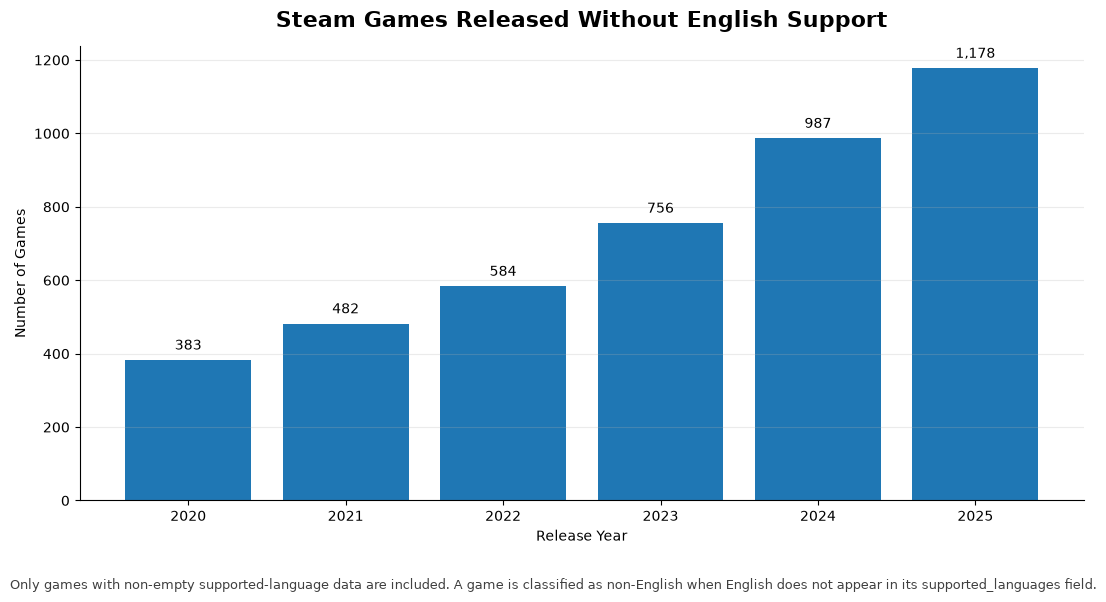

In [17]:
plot_data = english_support_summary.copy()

fig, ax = plt.subplots(figsize=(11, 6))

bars = ax.bar(
    plot_data["release_year"].astype(str),
    plot_data["games_without_english"]
)

for bar, value in zip(
    bars,
    plot_data["games_without_english"]
):
    ax.annotate(
        f"{int(value):,}",
        xy=(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height()
        ),
        xytext=(0, 5),
        textcoords="offset points",
        ha="center",
        va="bottom",
        fontsize=10
    )

ax.set_title(
    "Steam Games Released Without English Support",
    fontsize=16,
    weight="bold",
    pad=14
)

ax.set_xlabel("Release Year")
ax.set_ylabel("Number of Games")

ax.grid(
    axis="y",
    alpha=0.25
)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

fig.text(
    0.01,
    0.01,
    (
        "Only games with non-empty supported-language data are included. "
        "A game is classified as non-English when English does not appear "
        "in its supported_languages field."
    ),
    fontsize=9,
    alpha=0.75
)

plt.tight_layout(rect=[0, 0.06, 1, 1])
plt.show()

In [18]:
# Only games with at least one declared full-audio language
audio_language_df = df.loc[
    df["full_audio_languages_clean"].apply(len).gt(0)
].copy()

# English is not among the full-audio languages
non_english_audio_games = audio_language_df.loc[
    audio_language_df["release_year"].between(
        2020,
        2025,
        inclusive="both"
    )
    & ~audio_language_df["has_english_full_audio"]
].copy()

print(
    f"Games released from 2020–2025 with full audio, "
    f"but no English full audio: "
    f"{len(non_english_audio_games):,}"
)

Games released from 2020–2025 with full audio, but no English full audio: 4,352


In [19]:
non_english_audio_games[
    [
        "appid",
        "name",
        "release_year",
        "supported_languages_clean",
        "full_audio_languages_clean"
    ]
].sort_values(
    ["release_year", "name"]
).head(30)

,appid,name,release_year,supported_languages_clean,full_audio_languages_clean
57740,1352230,1917 : The Prologue,2020,"[English, Russian, Simplified Chinese]","[Russian, Simplified Chinese]"
67429,1142830,9-nine-:Episode 3,2020,"[English, Japanese, Traditional Chinese]","[Japanese, Traditional Chinese]"
20965,1442160,ABYSS OF THE SACRIFICE,2020,"[English, Simplified Chinese, Traditional Chin...",[Japanese]
41107,1250650,AI＊Shoujo/AI＊少女,2020,"[English, Japanese, Simplified Chinese, Tradit...","[Japanese, Traditional Chinese]"
4639,1229900,ARIA CHRONICLE,2020,"[English, Japanese, Korean, Simplified Chinese...","[Japanese, Traditional Chinese]"
26454,1230140,ATRI -My Dear Moments-,2020,"[English, Simplified Chinese, Traditional Chin...",[Japanese]
38475,1387580,AbsentedAge: Squarebound,2020,"[Japanese, Simplified Chinese, Traditional Chi...","[Japanese, Korean]"
117077,1335200,Action Taimanin,2020,"[English, Japanese, Simplified Chinese, Tradit...","[Japanese, Spanish - Latin America]"
87445,1094820,Adabana Odd Tales,2020,"[English, Simplified Chinese, Traditional Chin...",[Japanese]
25040,1333350,Angel Legion,2020,"[English, Simplified Chinese, Traditional Chin...","[Simplified Chinese, Traditional Chinese, Japa..."


In [20]:
non_english_audio_by_year = (
    non_english_audio_games
    .groupby("release_year")
    .agg(
        games_without_english_audio=("appid", "nunique")
    )
    .reset_index()
)

non_english_audio_by_year

,release_year,games_without_english_audio
0,2020,399
1,2021,472
2,2022,577
3,2023,707
4,2024,1003
5,2025,1194


In [21]:
audio_period = audio_language_df.loc[
    audio_language_df["release_year"].between(
        2020,
        2025,
        inclusive="both"
    )
].copy()

audio_support_summary = (
    audio_period
    .groupby("release_year")
    .agg(
        games_with_full_audio=("appid", "nunique"),
        games_with_english_audio=(
            "has_english_full_audio",
            "sum"
        )
    )
    .reset_index()
)

audio_support_summary["games_without_english_audio"] = (
    audio_support_summary["games_with_full_audio"]
    - audio_support_summary["games_with_english_audio"]
)

audio_support_summary["share_without_english_audio"] = (
    100
    * audio_support_summary["games_without_english_audio"]
    / audio_support_summary["games_with_full_audio"]
)

audio_support_summary

,release_year,games_with_full_audio,games_with_english_audio,games_without_english_audio,share_without_english_audio
0,2020,3858,3459,399,10.342146
1,2021,4233,3761,472,11.150484
2,2022,4848,4271,577,11.901815
3,2023,5757,5050,707,12.280702
4,2024,7870,6867,1003,12.744600
5,2025,9009,7815,1194,13.253413


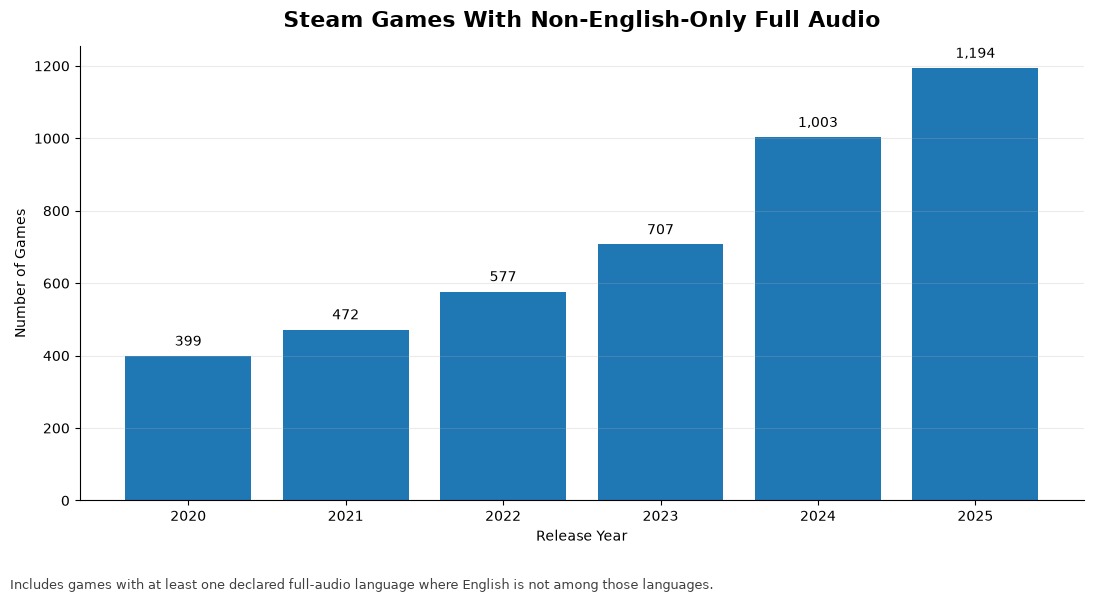

In [22]:
import matplotlib.pyplot as plt

plot_data = audio_support_summary.copy()

fig, ax = plt.subplots(figsize=(11, 6))

bars = ax.bar(
    plot_data["release_year"].astype(str),
    plot_data["games_without_english_audio"]
)

for bar, value in zip(
    bars,
    plot_data["games_without_english_audio"]
):
    ax.annotate(
        f"{int(value):,}",
        xy=(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height()
        ),
        xytext=(0, 5),
        textcoords="offset points",
        ha="center",
        va="bottom",
        fontsize=10
    )

ax.set_title(
    "Steam Games With Non-English-Only Full Audio",
    fontsize=16,
    weight="bold",
    pad=14
)

ax.set_xlabel("Release Year")
ax.set_ylabel("Number of Games")

ax.grid(axis="y", alpha=0.25)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

fig.text(
    0.01,
    0.01,
    (
        "Includes games with at least one declared full-audio "
        "language where English is not among those languages."
    ),
    fontsize=9,
    alpha=0.75
)

plt.tight_layout(rect=[0, 0.06, 1, 1])
plt.show()

In [23]:
def has_non_english_audio(audio_languages):
    return any(
        language.casefold() != "english"
        for language in audio_languages
    )

audio_language_df = df.loc[
    df["full_audio_languages_clean"].apply(len).gt(0)
].copy()

audio_language_df["has_non_english_audio"] = (
    audio_language_df["full_audio_languages_clean"]
    .apply(has_non_english_audio)
)

In [24]:
regional_audio_games = audio_language_df.loc[
    audio_language_df["release_year"].between(2020, 2025)
    &
    audio_language_df["has_non_english_audio"]
].copy()

print(f"{len(regional_audio_games):,} games have at least one non-English full-audio language.")

18,128 games have at least one non-English full-audio language.


In [25]:
regional_audio_summary = (
    audio_language_df.loc[
        audio_language_df["release_year"].between(2020, 2025)
    ]
    .groupby("release_year")
    .agg(
        games_with_audio=("appid", "count"),
        games_with_non_english_audio=("has_non_english_audio", "sum")
    )
    .reset_index()
)

regional_audio_summary["share"] = (
    100
    * regional_audio_summary["games_with_non_english_audio"]
    / regional_audio_summary["games_with_audio"]
)

regional_audio_summary

,release_year,games_with_audio,games_with_non_english_audio,share
0,2020,3858,1759,45.593572
1,2021,4233,2018,47.673045
2,2022,4848,2327,47.999175
3,2023,5757,2973,51.641480
4,2024,7870,4234,53.799238
5,2025,9009,4817,53.468753


In [26]:
REVIEW_MULTIPLIER = 45

df["positive"] = pd.to_numeric(
    df["positive"],
    errors="coerce"
).fillna(0)

df["negative"] = pd.to_numeric(
    df["negative"],
    errors="coerce"
).fillna(0)

df["price"] = pd.to_numeric(
    df["price"],
    errors="coerce"
).fillna(0)

df["total_reviews"] = (
    df["positive"] + df["negative"]
)

df["estimated_revenue"] = (
    df["total_reviews"]
    * REVIEW_MULTIPLIER
    * df["price"]
)

In [27]:
def has_non_english_audio(audio_languages):
    return any(
        str(language).strip().casefold() != "english"
        for language in audio_languages
    )


df["has_full_audio"] = (
    df["full_audio_languages_clean"]
    .apply(len)
    .gt(0)
)

df["has_regional_audio"] = (
    df["full_audio_languages_clean"]
    .apply(has_non_english_audio)
)

df[
    [
        "name",
        "release_year",
        "full_audio_languages_clean",
        "has_full_audio",
        "has_regional_audio"
    ]
].head()

,name,release_year,full_audio_languages_clean,has_full_audio,has_regional_audio
0,Black Dragon Mage Playtest,2023,[],False,False
1,Supipara - Chapter 1 Spring Has Come!,2016,[],False,False
2,Mystery Solitaire The Black Raven,2019,[],False,False
3,버튜버 파라노이아 - Vtuber Paranoia,2024,[Korean],True,True
4,Maze Quest VR,2025,[English],True,False


In [28]:
analysis_df = df.loc[
    df["release_year"].between(2020, 2024)
    & df["price"].gt(0)
    & df["release_date"].notna()
].copy()

analysis_df["audio_business_model"] = np.where(
    analysis_df["has_regional_audio"],
    "Regional audio",
    "No regional audio"
)

print(f"Analysis sample: {len(analysis_df):,} games")

analysis_df["audio_business_model"].value_counts()

Analysis sample: 51,443 games


audio_business_model
No regional audio    40066
Regional audio       11377
Name: count, dtype: int64

In [29]:
full_audio_comparison = analysis_df.loc[
    analysis_df["has_full_audio"]
].copy()

full_audio_comparison["audio_model"] = np.where(
    full_audio_comparison["has_regional_audio"],
    "Regional audio",
    "English-only audio"
)

full_audio_comparison["audio_model"].value_counts()

audio_model
Regional audio        11377
English-only audio    10232
Name: count, dtype: int64

In [30]:
def business_model_summary(data, group_column):
    return (
        data
        .groupby(group_column)
        .agg(
            games=("appid", "nunique"),
            median_revenue=("estimated_revenue", "median"),
            mean_revenue=("estimated_revenue", "mean"),
            total_revenue=("estimated_revenue", "sum"),
            median_reviews=("total_reviews", "median"),
            mean_price=("price", "mean"),
            zero_review_share=(
                "total_reviews",
                lambda x: 100 * x.eq(0).mean()
            ),
            revenue_over_100k=(
                "estimated_revenue",
                lambda x: 100 * x.ge(100_000).mean()
            ),
            revenue_over_500k=(
                "estimated_revenue",
                lambda x: 100 * x.ge(500_000).mean()
            ),
            revenue_over_1m=(
                "estimated_revenue",
                lambda x: 100 * x.ge(1_000_000).mean()
            )
        )
        .reset_index()
    )


audio_revenue_summary = business_model_summary(
    full_audio_comparison,
    "audio_model"
)

display(
    audio_revenue_summary.style.format({
        "games": "{:,.0f}",
        "median_revenue": "${:,.0f}",
        "mean_revenue": "${:,.0f}",
        "total_revenue": "${:,.0f}",
        "median_reviews": "{:,.0f}",
        "mean_price": "${:,.2f}",
        "zero_review_share": "{:.1f}%",
        "revenue_over_100k": "{:.1f}%",
        "revenue_over_500k": "{:.1f}%",
        "revenue_over_1m": "{:.1f}%"
    })
)

,audio_model,games,median_revenue,mean_revenue,total_revenue,median_reviews,mean_price,zero_review_share,revenue_over_100k,revenue_over_500k,revenue_over_1m
0,English-only audio,"10,232",$898,"$72,196","$738,706,842",7,$5.40,13.2%,3.5%,1.2%,0.7%
1,Regional audio,"11,377","$3,786","$2,211,478","$25,159,989,424",25,$7.31,15.7%,20.0%,10.7%,7.8%


In [31]:
threshold_summary = (
    full_audio_comparison
    .assign(
        earned_500k=lambda x:
        x["estimated_revenue"].ge(500_000)
    )
    .groupby(["release_year", "audio_model"])
    .agg(
        games=("appid", "nunique"),
        games_over_500k=("earned_500k", "sum"),
        success_rate=("earned_500k", "mean")
    )
    .reset_index()
)

threshold_summary["success_rate"] *= 100

threshold_summary

,release_year,audio_model,games,games_over_500k,success_rate
0,2020,English-only audio,1653,24,1.451906
1,2020,Regional audio,1524,212,13.910761
2,2021,English-only audio,1773,21,1.184433
3,2021,Regional audio,1739,212,12.190914
4,2022,English-only audio,1924,26,1.351351
5,2022,Regional audio,1973,231,11.708059
6,2023,English-only audio,2115,29,1.371158
7,2023,Regional audio,2544,254,9.984277
8,2024,English-only audio,2767,27,0.975786
9,2024,Regional audio,3597,304,8.451487


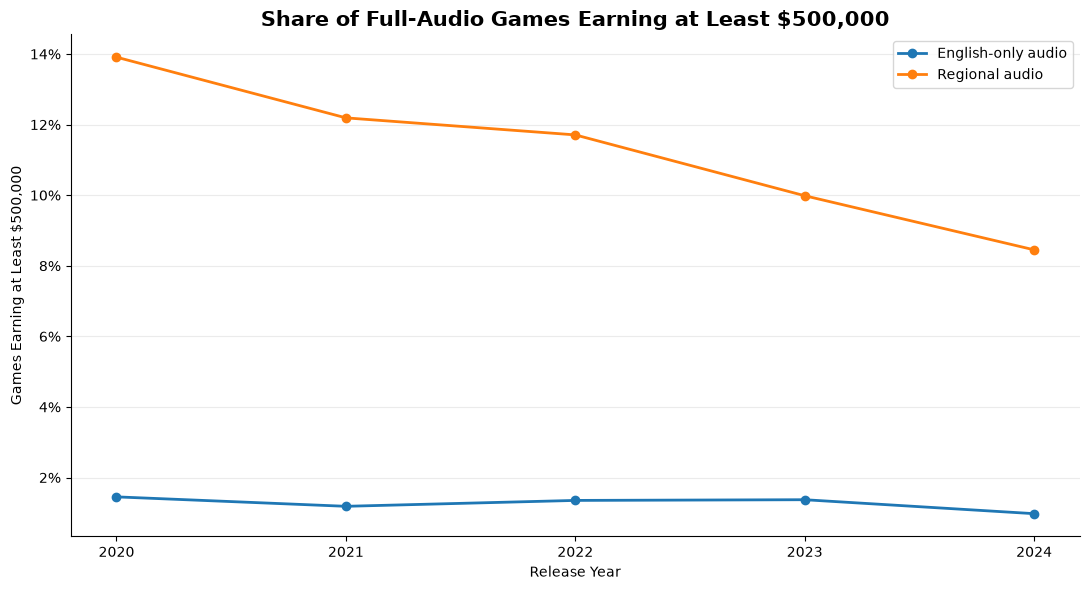

In [32]:
fig, ax = plt.subplots(figsize=(11, 6))

for group_name, group_data in threshold_summary.groupby("audio_model"):
    ax.plot(
        group_data["release_year"],
        group_data["success_rate"],
        marker="o",
        linewidth=2,
        label=group_name
    )

ax.set_title(
    "Share of Full-Audio Games Earning at Least $500,000",
    fontsize=15,
    weight="bold"
)

ax.set_xlabel("Release Year")
ax.set_ylabel("Games Earning at Least $500,000")
ax.set_xticks(range(2020, 2025))

ax.yaxis.set_major_formatter(
    FuncFormatter(lambda value, position: f"{value:.0f}%")
)

ax.legend()
ax.grid(axis="y", alpha=0.25)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.show()

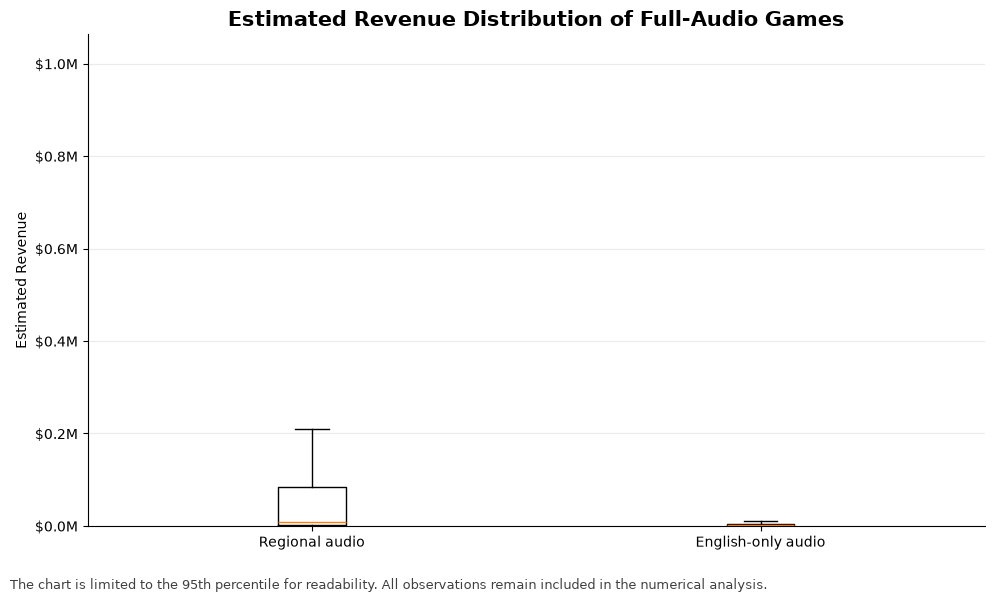

In [33]:
plot_df = full_audio_comparison.loc[
    full_audio_comparison["estimated_revenue"].gt(0)
].copy()

display_limit = plot_df["estimated_revenue"].quantile(0.95)

regional_values = plot_df.loc[
    plot_df["audio_model"].eq("Regional audio"),
    "estimated_revenue"
]

english_only_values = plot_df.loc[
    plot_df["audio_model"].eq("English-only audio"),
    "estimated_revenue"
]

fig, ax = plt.subplots(figsize=(10, 6))

ax.boxplot(
    [regional_values, english_only_values],
    tick_labels=[
        "Regional audio",
        "English-only audio"
    ],
    showfliers=False
)

ax.set_ylim(0, display_limit)

ax.set_title(
    "Estimated Revenue Distribution of Full-Audio Games",
    fontsize=15,
    weight="bold"
)

ax.set_ylabel("Estimated Revenue")
ax.yaxis.set_major_formatter(
    FuncFormatter(
        lambda value, position: f"${value / 1_000_000:.1f}M"
    )
)

ax.grid(axis="y", alpha=0.25)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

fig.text(
    0.01,
    0.01,
    (
        "The chart is limited to the 95th percentile for readability. "
        "All observations remain included in the numerical analysis."
    ),
    fontsize=9,
    alpha=0.75
)

plt.tight_layout(rect=[0, 0.05, 1, 1])
plt.show()

In [34]:
from scipy.stats import mannwhitneyu

regional_revenue = full_audio_comparison.loc[
    full_audio_comparison["audio_model"].eq("Regional audio"),
    "estimated_revenue"
]

english_only_revenue = full_audio_comparison.loc[
    full_audio_comparison["audio_model"].eq("English-only audio"),
    "estimated_revenue"
]

statistic, p_value = mannwhitneyu(
    regional_revenue,
    english_only_revenue,
    alternative="two-sided"
)

print(f"Mann–Whitney statistic: {statistic:,.0f}")
print(f"P-value: {p_value:.6f}")

Mann–Whitney statistic: 74,068,682
P-value: 0.000000


In [35]:
median_by_model = (
    full_audio_comparison
    .groupby("audio_model")["estimated_revenue"]
    .median()
)

regional_median = median_by_model["Regional audio"]
english_only_median = median_by_model["English-only audio"]

median_difference = regional_median - english_only_median

if english_only_median > 0:
    median_multiple = regional_median / english_only_median
else:
    median_multiple = np.nan

print(f"Regional-audio median: ${regional_median:,.0f}")
print(f"English-only median:   ${english_only_median:,.0f}")
print(f"Absolute difference:   ${median_difference:,.0f}")
print(f"Revenue multiple:      {median_multiple:.2f}x")

Regional-audio median: $3,786
English-only median:   $898
Absolute difference:   $2,888
Revenue multiple:      4.21x


In [36]:
yearly_audio_performance = (
    full_audio_comparison
    .groupby(["release_year", "audio_model"])
    .agg(
        games=("appid", "nunique"),
        median_revenue=("estimated_revenue", "median"),
        mean_revenue=("estimated_revenue", "mean"),
        success_rate_500k=(
            "estimated_revenue",
            lambda x: 100 * x.ge(500_000).mean()
        )
    )
    .reset_index()
)

display(
    yearly_audio_performance.style.format({
        "games": "{:,.0f}",
        "median_revenue": "${:,.0f}",
        "mean_revenue": "${:,.0f}",
        "success_rate_500k": "{:.1f}%"
    })
)

,release_year,audio_model,games,median_revenue,mean_revenue,success_rate_500k
0,2020,English-only audio,"1,653","$1,348","$117,698",1.5%
1,2020,Regional audio,"1,524","$8,070","$3,007,017",13.9%
2,2021,English-only audio,"1,773",$944,"$38,512",1.2%
3,2021,Regional audio,"1,739","$4,980","$1,973,107",12.2%
4,2022,English-only audio,"1,924","$1,078","$45,666",1.4%
5,2022,Regional audio,"1,973","$4,674","$2,161,418",11.7%
6,2023,English-only audio,"2,115",$809,"$111,612",1.4%
7,2023,Regional audio,"2,544","$3,083","$1,670,467",10.0%
8,2024,English-only audio,"2,767",$538,"$54,915",1.0%
9,2024,Regional audio,"3,597","$2,577","$2,399,755",8.5%


In [37]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter


def standardize_audio_language(language):
    """
    Convert Steam language labels into consistent analysis categories.
    """

    language = str(language).strip().casefold()

    aliases = {
        "english": "English",

        "korean": "Korean",

        "arabic": "Arabic",

        "simplified chinese": "Chinese",
        "traditional chinese": "Chinese",
        "chinese": "Chinese",

        "japanese": "Japanese",

        "russian": "Russian",

        "turkish": "Turkish",

        "german": "German",

        "french": "French",

        "spanish - spain": "Spanish",
        "spanish - latin america": "Spanish",
        "spanish": "Spanish",

        "portuguese - brazil": "Brazilian Portuguese",
        "brazilian portuguese": "Brazilian Portuguese",
        "portuguese": "Portuguese",
    }

    return aliases.get(
        language,
        str(language).strip()
    )


def standardize_audio_list(language_list):
    """
    Standardize and deduplicate a game's full-audio languages.
    """

    if not isinstance(language_list, list):
        return []

    cleaned = [
        standardize_audio_language(language)
        for language in language_list
        if str(language).strip()
    ]

    # Remove duplicates while preserving order
    return list(dict.fromkeys(cleaned))


df["audio_languages_standardized"] = (
    df["full_audio_languages_clean"]
    .apply(standardize_audio_list)
)

df[
    [
        "name",
        "full_audio_languages_clean",
        "audio_languages_standardized"
    ]
].head(10)

,name,full_audio_languages_clean,audio_languages_standardized
0,Black Dragon Mage Playtest,[],[]
1,Supipara - Chapter 1 Spring Has Come!,[],[]
2,Mystery Solitaire The Black Raven,[],[]
3,버튜버 파라노이아 - Vtuber Paranoia,[Korean],[Korean]
4,Maze Quest VR,[English],[English]
5,Agony VR,"[English, Turkish]","[English, Turkish]"
6,Armored Brigade II,[],[]
7,Galacatraz: Eject Equip Escape,[English],[English]
8,Hepta Beats,"[English, French, Italian, German, Spanish - S...","[English, French, italian, German, Spanish, bu..."
9,MUMBA IV: Egypt Jewels,[],[]


In [38]:
SINGLE_LANGUAGE_GROUPS = {
    "English",
    "Korean",
    "Arabic",
    "Chinese",
    "Japanese",
    "Russian",
    "Turkish",
    "German",
    "Brazilian Portuguese",
}


def classify_audio_market(audio_languages):
    """
    Assign a mutually exclusive full-audio market category.
    """

    language_count = len(audio_languages)

    if language_count == 0:
        return "No declared full audio"

    if language_count == 1:
        only_language = audio_languages[0]

        if only_language in SINGLE_LANGUAGE_GROUPS:
            return f"{only_language} only"

        return "Other language only"

    # Two or more languages with at least one non-English language
    if any(language != "English" for language in audio_languages):
        return "Regional / multilingual audio"

    # Normally impossible after deduplication, but kept as a safeguard
    return "English only"


df["audio_market"] = (
    df["audio_languages_standardized"]
    .apply(classify_audio_market)
)

df["audio_market"].value_counts()

audio_market
No declared full audio           80270
English only                     27796
Regional / multilingual audio    23228
Chinese only                      1863
Japanese only                      916
Other language only                387
Russian only                       291
Korean only                        132
Brazilian Portuguese only          107
German only                         89
Turkish only                        41
Arabic only                         20
Name: count, dtype: int64

In [39]:
REVIEW_MULTIPLIER = 45
START_YEAR = 2020
END_YEAR = 2024
REVENUE_THRESHOLD = 500_000


for column in ["positive", "negative", "price"]:
    df[column] = pd.to_numeric(
        df[column],
        errors="coerce"
    ).fillna(0)


df["total_reviews"] = (
    df["positive"] + df["negative"]
)


if "estimated_revenue" not in df.columns:
    df["estimated_revenue"] = (
        df["total_reviews"]
        * REVIEW_MULTIPLIER
        * df["price"]
    )


language_audio_analysis = df.loc[
    df["release_year"].between(
        START_YEAR,
        END_YEAR,
        inclusive="both"
    )
    & df["price"].gt(0)
    & ~df["audio_market"].eq("No declared full audio")
].copy()


language_audio_analysis["earned_over_threshold"] = (
    language_audio_analysis["estimated_revenue"]
    .ge(REVENUE_THRESHOLD)
)


print(
    f"Analysis sample: {len(language_audio_analysis):,} games"
)

print(
    language_audio_analysis["audio_market"]
    .value_counts()
)

Analysis sample: 21,609 games
audio_market
English only                     10232
Regional / multilingual audio     9785
Chinese only                       744
Japanese only                      441
Other language only                141
Russian only                       111
Korean only                         50
Brazilian Portuguese only           50
German only                         31
Turkish only                        17
Arabic only                          7
Name: count, dtype: int64


In [40]:
MINIMUM_GROUP_SIZE = 30

audio_group_sizes = (
    language_audio_analysis
    .groupby("audio_market")
    .agg(
        games=("appid", "nunique")
    )
    .sort_values("games", ascending=False)
)

audio_group_sizes

,games
audio_market,
English only,10232
Regional / multilingual audio,9785
Chinese only,744
Japanese only,441
Other language only,141
Russian only,111
Brazilian Portuguese only,50
Korean only,50
German only,31


In [41]:
audio_market_summary = (
    language_audio_analysis
    .groupby("audio_market")
    .agg(
        games=("appid", "nunique"),

        median_revenue=(
            "estimated_revenue",
            "median"
        ),

        mean_revenue=(
            "estimated_revenue",
            "mean"
        ),

        median_reviews=(
            "total_reviews",
            "median"
        ),

        success_100k=(
            "estimated_revenue",
            lambda values:
            100 * values.ge(100_000).mean()
        ),

        success_500k=(
            "estimated_revenue",
            lambda values:
            100 * values.ge(500_000).mean()
        ),

        success_1m=(
            "estimated_revenue",
            lambda values:
            100 * values.ge(1_000_000).mean()
        ),
    )
    .reset_index()
)

audio_market_summary = (
    audio_market_summary.loc[
        audio_market_summary["games"] >= MINIMUM_GROUP_SIZE
    ]
    .sort_values(
        "success_500k",
        ascending=False
    )
)

display(
    audio_market_summary.style.format({
        "games": "{:,.0f}",
        "median_revenue": "${:,.0f}",
        "mean_revenue": "${:,.0f}",
        "median_reviews": "{:,.0f}",
        "success_100k": "{:.1f}%",
        "success_500k": "{:.1f}%",
        "success_1m": "{:.1f}%"
    }).hide(axis="index")
)

audio_market,games,median_revenue,mean_revenue,median_reviews,success_100k,success_500k,success_1m
Regional / multilingual audio,"9,785","$4,119","$2,552,056",27,21.6%,11.8%,8.8%
Japanese only,441,"$1,887","$123,125",7,14.5%,4.8%,2.7%
Korean only,50,"$6,862","$962,353",18,6.0%,4.0%,2.0%
Chinese only,744,"$3,447","$107,775",22,11.7%,3.9%,1.9%
Other language only,141,$675,"$24,085",5,5.0%,1.4%,0.7%
English only,"10,232",$898,"$72,196",7,3.5%,1.2%,0.7%
Brazilian Portuguese only,50,$538,"$8,969",7,2.0%,0.0%,0.0%
German only,31,"$1,572","$9,704",7,3.2%,0.0%,0.0%
Russian only,111,"$1,754","$8,961",30,2.7%,0.0%,0.0%


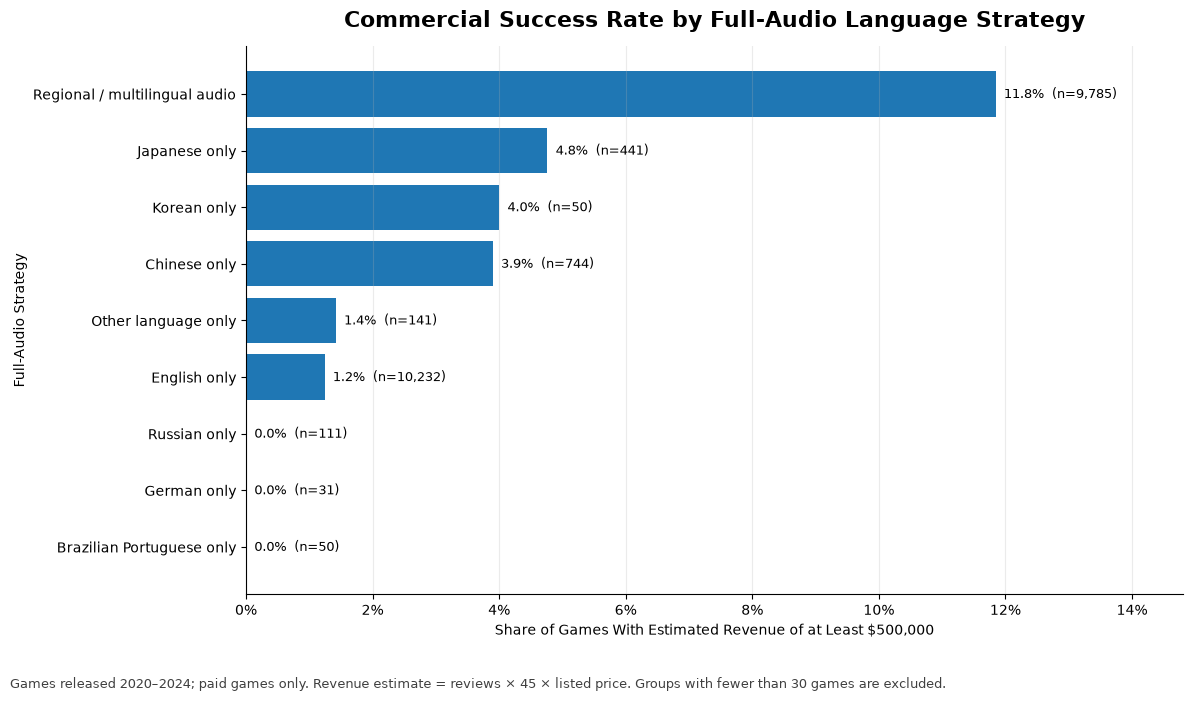

In [42]:
plot_summary = (
    audio_market_summary
    .sort_values("success_500k")
    .copy()
)

fig, ax = plt.subplots(figsize=(12, 7))

bars = ax.barh(
    plot_summary["audio_market"],
    plot_summary["success_500k"]
)

for bar, success_rate, game_count in zip(
    bars,
    plot_summary["success_500k"],
    plot_summary["games"]
):
    ax.annotate(
        f"{success_rate:.1f}%  (n={int(game_count):,})",
        xy=(
            bar.get_width(),
            bar.get_y() + bar.get_height() / 2
        ),
        xytext=(6, 0),
        textcoords="offset points",
        ha="left",
        va="center",
        fontsize=9
    )

ax.set_title(
    "Commercial Success Rate by Full-Audio Language Strategy",
    fontsize=16,
    fontweight="bold",
    pad=14
)

ax.set_xlabel(
    "Share of Games With Estimated Revenue of at Least $500,000"
)

ax.set_ylabel("Full-Audio Strategy")

ax.xaxis.set_major_formatter(
    FuncFormatter(
        lambda value, position: f"{value:.0f}%"
    )
)

ax.set_xlim(
    0,
    plot_summary["success_500k"].max() * 1.25
)

ax.grid(
    axis="x",
    alpha=0.25
)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

fig.text(
    0.01,
    0.01,
    (
        f"Games released {START_YEAR}–{END_YEAR}; paid games only. "
        f"Revenue estimate = reviews × {REVIEW_MULTIPLIER} × listed price. "
        f"Groups with fewer than {MINIMUM_GROUP_SIZE} games are excluded."
    ),
    fontsize=9,
    alpha=0.75
)

plt.tight_layout(rect=[0, 0.06, 1, 1])
plt.show()

In [43]:
selected_audio_groups = [
    "English only",
    "Korean only",
    "Arabic only",
    "Chinese only",
    "Japanese only",
    "Russian only",
    "Turkish only",
    "Regional / multilingual audio",
]

yearly_audio_success = (
    language_audio_analysis.loc[
        language_audio_analysis["audio_market"]
        .isin(selected_audio_groups)
    ]
    .groupby(
        ["release_year", "audio_market"]
    )
    .agg(
        games=("appid", "nunique"),
        success_rate=(
            "earned_over_threshold",
            "mean"
        )
    )
    .reset_index()
)

yearly_audio_success["success_rate"] *= 100

# Avoid displaying extremely unstable year/group combinations
yearly_audio_success = yearly_audio_success.loc[
    yearly_audio_success["games"] >= 10
]

yearly_audio_success

,release_year,audio_market,games,success_rate
1,2020,Chinese only,96,5.208333
2,2020,English only,1653,1.451906
3,2020,Japanese only,58,5.172414
5,2020,Regional / multilingual audio,1314,15.449011
6,2020,Russian only,18,0.000000
9,2021,Chinese only,107,1.869159
10,2021,English only,1773,1.184433
11,2021,Japanese only,77,3.896104
13,2021,Regional / multilingual audio,1485,13.872054
14,2021,Russian only,25,0.000000


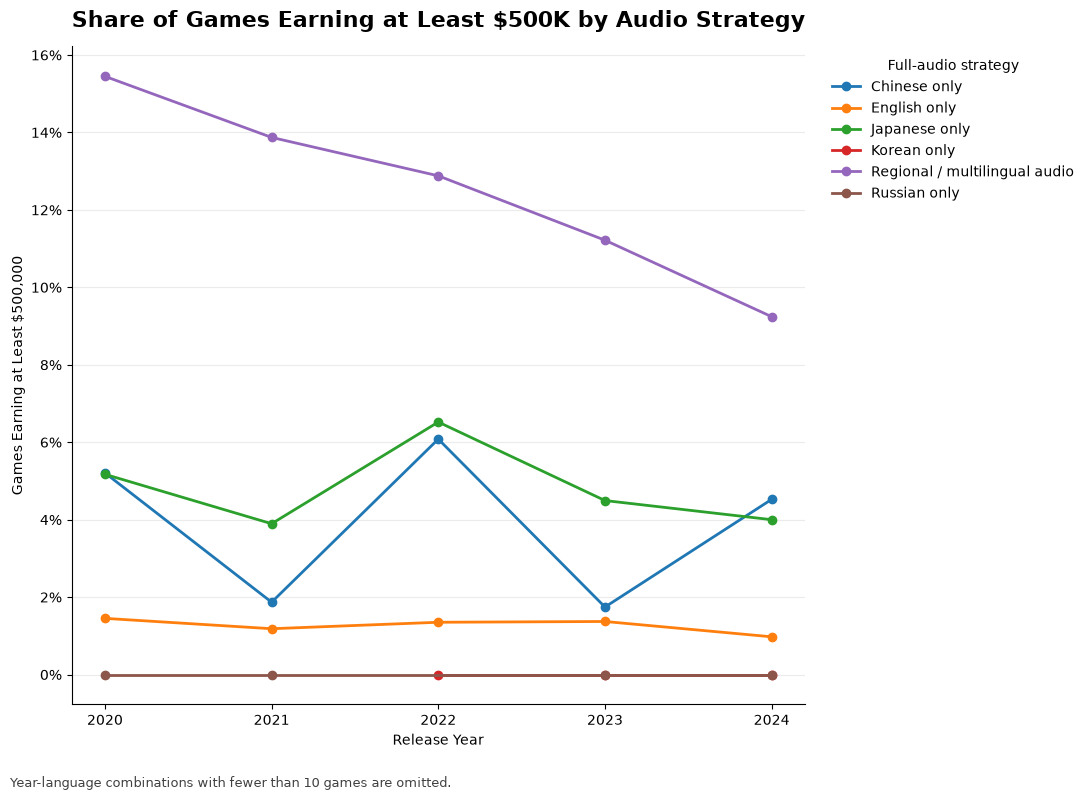

In [44]:
fig, ax = plt.subplots(figsize=(14, 8))

for audio_market, group_data in yearly_audio_success.groupby(
    "audio_market"
):
    group_data = group_data.sort_values("release_year")

    ax.plot(
        group_data["release_year"],
        group_data["success_rate"],
        marker="o",
        linewidth=2,
        label=audio_market
    )

ax.set_title(
    "Share of Games Earning at Least $500K by Audio Strategy",
    fontsize=16,
    fontweight="bold",
    pad=14
)

ax.set_xlabel("Release Year")
ax.set_ylabel("Games Earning at Least $500,000")

ax.set_xticks(range(START_YEAR, END_YEAR + 1))

ax.yaxis.set_major_formatter(
    FuncFormatter(
        lambda value, position: f"{value:.0f}%"
    )
)

ax.legend(
    title="Full-audio strategy",
    bbox_to_anchor=(1.02, 1),
    loc="upper left",
    frameon=False
)

ax.grid(
    axis="y",
    alpha=0.25
)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

fig.text(
    0.01,
    0.01,
    "Year-language combinations with fewer than 10 games are omitted.",
    fontsize=9,
    alpha=0.75
)

plt.tight_layout(rect=[0, 0.04, 0.79, 1])
plt.show()